# Bipartite graph scratch

In [57]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
import numpy as np
import polars as pl
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import optuna
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data, HeteroData
import networkx as nx
from torch_geometric.utils import to_networkx
import torch
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATv2Conv, to_hetero, RGATConv, HeteroConv, Linear
from sklearn.manifold import TSNE
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from torch.utils.data import DataLoader
from torchvision import transforms
import torch_geometric.transforms as T
import torch_geometric

from bipartite_gnn.graph_visualizatons import visualize_graph, visualize_embeddings
from baseline_evals.mlp_eval import MLP, MLPDataset, MLPTrainer

In [59]:
rna = pl.read_csv("xena_brca_data/TCGA.BRCA.sampleMap_HiSeqV2", separator="\t")

In [61]:
gene_names = rna[:,0]
rna = rna.drop("sample")

In [62]:
# load labels & filter rows with nulls
clinicalMatrix = pl.read_csv("xena_brca_data/TCGA.BRCA.sampleMap_BRCA_clinicalMatrix", separator="\t", infer_schema_length=0)
cM = clinicalMatrix.filter(pl.col("PAM50_mRNA_nature2012") != "null")

In [63]:
labels = cM.select(["sampleID","PAM50_mRNA_nature2012"])
labels = labels.filter(pl.col("PAM50_mRNA_nature2012") != "Normal-like")

In [64]:
y_all = labels["PAM50_mRNA_nature2012"].to_numpy()
# y_all

In [65]:
# display label counts
np.unique(labels["PAM50_mRNA_nature2012"].to_numpy(), return_counts=True)

(array(['Basal-like', 'HER2-enriched', 'Luminal A', 'Luminal B'],
       dtype=object),
 array([ 98,  58, 231, 127]))

In [66]:
rna = rna.select(labels["sampleID"].to_numpy())

In [67]:
# filter low var rows
rna_mat = rna.to_numpy()
rna_vars = rna_mat.var(axis=1)
high_var_mask = rna_vars > 0.1

np.unique(high_var_mask, return_counts=True)

high_var_idx = np.where(high_var_mask)[0]

gene_names = gene_names[high_var_idx]
rna = rna[high_var_idx]

print(rna.shape, gene_names.shape)

(18994, 514) (18994,)


In [68]:
label_encoder = LabelEncoder()
label_encoder.fit(y_all)
y_all_e = label_encoder.transform(y_all)

# add numberd labels to labels df
labels = labels.with_columns(y=y_all_e)

In [69]:
# labels and rna columns are aligned, do train, val, test split

# random split for train / test
train_idx, val_test_idx = train_test_split(
    np.arange(rna.shape[1]),
    test_size=0.2,
    stratify=y_all_e,
    random_state=4
)

In [70]:
val_idx, test_idx = train_test_split(
    val_test_idx, 
    test_size=0.5, 
    stratify=y_all_e[val_test_idx],                   
    random_state=4
)

In [71]:
# split dataframes
train_df = rna[:, train_idx.tolist()]
train_labels = labels[train_idx]
val_df = rna[:, val_idx.tolist()]
val_labels = labels[val_idx]
test_df = rna[:, test_idx.tolist()]
test_labels = labels[test_idx]

In [72]:
def variational_selection(X_train, y, n_features=500):
    """
    Given training data X_train (n_samples, n_features) and labels y (n_samples,)
    filter the features with class based variance
    """
    # select features based on the training set
    num_labels = len(np.unique(y))
    features_class_mean = np.zeros((X_train.shape[1], num_labels))

    # separate training samples by class
    for label in range(num_labels):
        X_class = X_train[y == label]
        features_class_mean[:, label] = X_class.mean(axis=0)

    feat_class_vars = features_class_mean.var(axis=1)
    class_var_order = np.argsort(feat_class_vars)

    # select the features with the largest variance
    best_mask = class_var_order >= (feat_class_vars.shape[0] - n_features)
    best_idx = np.where(best_mask)[0]

    return best_mask, best_idx

In [73]:
X_train = train_df.to_numpy().T
y_train = train_labels["y"].to_numpy()
X_val = val_df.to_numpy().T
y_val = val_labels["y"].to_numpy()
X_test = test_df.to_numpy().T
y_test = test_labels["y"].to_numpy()

best_500, best_500_idx = variational_selection(X_train, y_train, n_features=6000)

X_train = X_train[:, best_500]
X_val = X_val[:, best_500]
X_test = X_test[:, best_500]

best_500_genes = gene_names[best_500_idx].to_numpy()

# scale everything
std_scale = StandardScaler().fit(X_train)
X_train = std_scale.transform(X_train) 
X_val = std_scale.transform(X_val)
X_test = std_scale.transform(X_test)

In [74]:
# eval using knns
ks = (1, 30)

# eval on rbf svms
def objective_knn(trial):

    knn = KNeighborsClassifier(
        n_neighbors=trial.suggest_int("n_neighbors", ks[0], ks[1]),
        weights=trial.suggest_categorical("weights", ["uniform", "distance"]),
    )


    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_val)

    f1 = f1_score(y_val, y_pred, average="weighted")

    return f1

study = optuna.create_study(direction="maximize")
study.optimize(objective_knn, n_trials=200)

# print the mean f1 score for the best performing parameter
# print(
#     f"| RBF SVM | {best_results['acc']:.4f} +/- {best_results['acc_std']:.4f} | {best_results['f1_macro']:.4f} +/- {best_results['f1_macro_std']:.4f} | {best_results['f1_weighted']:.4f} +/- {best_results['f1_weighted_std']:.4f} |"
# )
print(f"study {study.best_value=}, {study.best_params=}")

[I 2024-04-15 15:17:10,651] A new study created in memory with name: no-name-163a2638-b36b-403d-bdc8-2773ed5c05bd
[I 2024-04-15 15:17:10,719] Trial 0 finished with value: 0.7266941864465085 and parameters: {'n_neighbors': 23, 'weights': 'uniform'}. Best is trial 0 with value: 0.7266941864465085.
[I 2024-04-15 15:17:10,735] Trial 1 finished with value: 0.7137254901960786 and parameters: {'n_neighbors': 16, 'weights': 'distance'}. Best is trial 0 with value: 0.7266941864465085.
[I 2024-04-15 15:17:10,750] Trial 2 finished with value: 0.7266941864465085 and parameters: {'n_neighbors': 18, 'weights': 'distance'}. Best is trial 0 with value: 0.7266941864465085.
[I 2024-04-15 15:17:10,765] Trial 3 finished with value: 0.7266941864465085 and parameters: {'n_neighbors': 21, 'weights': 'distance'}. Best is trial 0 with value: 0.7266941864465085.
[I 2024-04-15 15:17:10,781] Trial 4 finished with value: 0.7266941864465085 and parameters: {'n_neighbors': 22, 'weights': 'distance'}. Best is trial 0

study study.best_value=0.7649861545533023, study.best_params={'n_neighbors': 3, 'weights': 'uniform'}


In [75]:
knn = KNeighborsClassifier(
    n_neighbors=study.best_params["n_neighbors"],
    weights=study.best_params["weights"]
)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

f1 = f1_score(y_test, y_pred, average="weighted")

print("knn f1: ", f1)

knn f1:  0.6688770999115826


## KNNs
f1 score of ~0.65

In [24]:
C_range: tuple = (1e-3, 1e3)
gamma_range: tuple = (1e-3, 1e3)

# eval on rbf svms
def objective(trial):

    svm = SVC(
        C=trial.suggest_float("C", C_range[0], C_range[1], log=True),
        gamma=trial.suggest_float(
            "gamma", gamma_range[0], gamma_range[1], log=True
        ),
        class_weight=trial.suggest_categorical("class_weight", ["balanced", None]),
        kernel="rbf",
    )

    svm.fit(X_train, y_train)
    
    y_pred = svm.predict(X_val)

    f1 = f1_score(y_val, y_pred, average="weighted")

    return f1

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200)

# print the mean f1 score for the best performing parameter
# print(
#     f"| RBF SVM | {best_results['acc']:.4f} +/- {best_results['acc_std']:.4f} | {best_results['f1_macro']:.4f} +/- {best_results['f1_macro_std']:.4f} | {best_results['f1_weighted']:.4f} +/- {best_results['f1_weighted_std']:.4f} |"
# )
print(f"study {study.best_value=}, {study.best_params=}")

[I 2024-04-14 16:30:28,423] A new study created in memory with name: no-name-c5263ece-4f0f-4eb6-82e2-4312f3e2c372


[I 2024-04-14 16:30:28,572] Trial 0 finished with value: 0.28033916269210385 and parameters: {'C': 53.67785616997287, 'gamma': 2.268266730913626, 'class_weight': None}. Best is trial 0 with value: 0.28033916269210385.
[I 2024-04-14 16:30:28,705] Trial 1 finished with value: 0.28033916269210385 and parameters: {'C': 0.001920614072353826, 'gamma': 9.236760344849017, 'class_weight': None}. Best is trial 0 with value: 0.28033916269210385.
[I 2024-04-14 16:30:28,843] Trial 2 finished with value: 0.28033916269210385 and parameters: {'C': 12.57100634744789, 'gamma': 0.024792992140932838, 'class_weight': None}. Best is trial 0 with value: 0.28033916269210385.
[I 2024-04-14 16:30:28,986] Trial 3 finished with value: 0.024767801857585137 and parameters: {'C': 0.001196606359023886, 'gamma': 0.7744797951194848, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.28033916269210385.
[I 2024-04-14 16:30:29,131] Trial 4 finished with value: 0.28033916269210385 and parameters: {'C': 403.07607031

study study.best_value=0.7015364691562105, study.best_params={'C': 107.40640120915582, 'gamma': 0.0010295785382237342, 'class_weight': 'balanced'}


In [25]:
# fit model with best params and test on test set
svm = SVC(
        C=study.best_params["C"],
        gamma=study.best_params["gamma"],
        class_weight=study.best_params["class_weight"],
        kernel="rbf",
)

svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

f1 = f1_score(y_test, y_pred, average="weighted")

print("svm f1: ", f1)

svm f1:  0.6282200860240787


## SVMs with rbf kernel
- weighted f1 score with ~0.83 on test set

# Classical neural network

In [26]:
X_train, X_val, X_test = torch.tensor(X_train), torch.tensor(X_val), torch.tensor(X_test)
y_train, y_val, y_test = torch.tensor(y_train), torch.tensor(y_val), torch.tensor(y_test)

# Convert data to torch.float32
X_train = X_train.float()
X_val = X_val.float()
X_test = X_test.float()

# Create datasets with transforms (assuming your data is suitable for ToTensor)
train_dataset = MyDataset(X_train, y_train)
val_dataset = MyDataset(X_val, y_val)
test_dataset = MyDataset(X_test, y_test)

batch_size = 32  # Adjust batch size based on your hardware and data size

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=11)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=11)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=11)

NameError: name 'MyDataset' is not defined

In [291]:
# Create model instance
model = MLP(
    input_sz=X_train.shape[1],
    num_classes=len(np.unique(y_train)),
    hidden_channels=32
)

# Create LightningModule instance
mlp = MLPTrainer(model)

# Create PyTorch Lightning Trainer
trainer = L.Trainer(
    max_epochs=40,
    log_every_n_steps=1,
    callbacks=[EarlyStopping(monitor="val_loss", mode="min")],
)

# Train the model
trainer.fit(
    model=mlp,
    train_dataloaders=train_loader,  # Fixed the argument name
    val_dataloaders=val_loader  # Added validation data
)

# Test the model
trainer.test(
    model=mlp,
    dataloaders=test_loader  # Fixed the argument name
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/lubojjan/micromamba/envs/diploma/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/home/lubojjan/micromamba/envs/diploma/lib/python3.12/site-packages/lightning/pytorch/core/optimizer.py:376: Found unsupported keys in the optimizer configuration: {'lr_scheduler_config'}

  | Name | Type | Params
------------------------------
0 | net  | MLP  | 16.2 K
------------------------------


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Testing: |                                                                                                    …

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         test_f1            0.7925633192062378
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_f1': 0.7925633192062378}]

## MLP results
so with a simple MLP we get about the same results as with rbf svm, ~
0.835

## Mogonet style gnn

In [76]:
def cosine_similarity_matrix(matrix):
    """
    given a matrix of (n_samples, n_features) compute the cosine similarities, between the samples
    """
    # Compute dot product between all pairs of vectors
    dot_products = np.dot(matrix, matrix.T)
    
    # Compute magnitudes of all vectors
    magnitudes = np.linalg.norm(matrix, axis=1)
    
    # Compute outer product of magnitudes to obtain matrix of magnitudes product
    magnitude_products = np.outer(magnitudes, magnitudes)
    
    # Compute cosine similarity matrix
    cosine_similarities = dot_products / magnitude_products
    
    return cosine_similarities

def keep_n_neighbours(A, n):
      rows, cols = A.shape
      for i in range(rows):
        # Find indices of the k highest elements
        bottom_k_indices = np.argsort(A[i])[:-n]
        # Set all other elements to zero
        A[i][bottom_k_indices] = 0
      return A
    

def dense_to_coo(adj_mat):
    """
    convert an adjacency matrix in a dense format to a torch tensor in COO format
    """
    indices = np.where(adj_mat != 0)
    indices = np.vstack((indices[0], indices[1]))
    return torch.tensor(indices, dtype=torch.int64)
    
def dense_to_attributes(adj_mat):
    """
    return the flattened weight entries from the matrix
    for use as edge attributes
    """
    return torch.tensor(adj_mat[adj_mat != 0]).view(-1,1)
    

In [96]:
gat_layer = torch_geometric.nn.GATv2Conv(1024, 32, heads=1, concat=True)

In [101]:
for p in gat_layer.parameters():
    print(p.shape)

torch.Size([1, 1, 32])
torch.Size([32])
torch.Size([32, 1024])
torch.Size([32])
torch.Size([32, 1024])
torch.Size([32])


In [89]:
from torch_geometric.nn import GCNConv


class GCN(torch.nn.Module):
    def __init__(self, input_sz, n_classes, hidden_channels):
        super().__init__()
        torch.manual_seed(1234567)
        self.conv1 = GCNConv(input_sz, hidden_channels, add_self_loops=False)
        self.conv2 = GCNConv(hidden_channels, n_classes, add_self_loops=False)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class GAT(torch.nn.Module):
    def __init__(self, input_sz, n_classes, hidden_channels, heads):
        super().__init__()
        torch.manual_seed(1234567)
        self.conv1 = GATv2Conv(input_sz, hidden_channels, heads, dropout=0.6, add_self_loops=False)
        self.conv2 = GATv2Conv(hidden_channels * heads, n_classes, heads=1, concat=False, dropout=0.6, add_self_loops=False)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.4, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.4, training=self.training)
        x= self.conv2(x, edge_index)
        return x

torch.Size([514, 6000])
torch.Size([2, 514])
num of isolated nodees 6


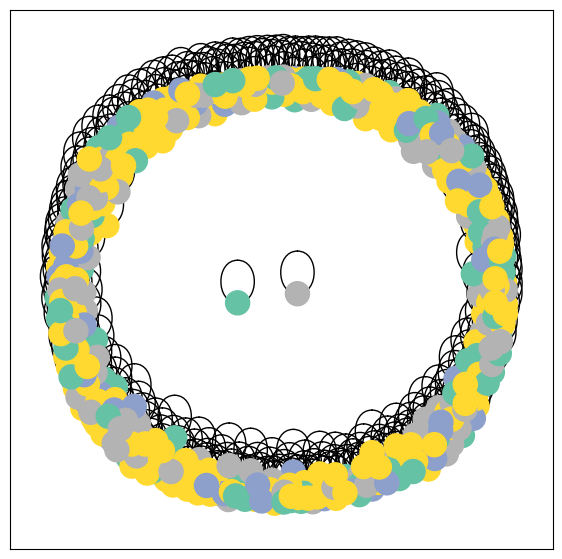

In [91]:
# build mogonet style GNN with
# a. thresholded cosine similarity

# transform features to (n_samples, n_features) tensor
X = rna.to_numpy().T
X = X[:, best_500]


# construct adjacency matrix
eps = 0.999
n = 10
A = cosine_similarity_matrix(X)
# A = keep_n_neighbours(A, n)
A[np.abs(A) < eps] = 0

X = std_scale.transform(X)
X = torch.tensor(X, dtype=torch.float32)
print(X.shape)

# construct edge indices
edge_indices = dense_to_coo(A)
print(edge_indices.shape)

# construct training mask
train_mask = np.zeros(X.shape[0], dtype=bool)
train_mask[train_idx] = True
train_mask = torch.tensor(train_mask)

val_mask = np.zeros(X.shape[0], dtype=bool)
val_mask[val_idx] = True
val_mask = torch.tensor(val_mask)

test_mask = np.zeros(X.shape[0], dtype=bool)
test_mask[test_idx] = True
test_mask = torch.tensor(test_mask)

y = torch.tensor(y_all_e, dtype=torch.int64)

data = Data(
    x=X,
    edge_index=edge_indices,
    y=y,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
)

print(f"num of isolated nodees {np.sum(A.sum(axis=1) == 1)}")

G = to_networkx(data, to_undirected=True)
visualize_graph(G, color=data.y)

In [94]:
# model = GCN(
#     input_sz=X_train.shape[1],
#     n_classes=len(np.unique(y_train)),
#     hidden_channels=32,
# )
model = GAT(
    input_sz=X_train.shape[1],
    n_classes=len(np.unique(y_train)),
    hidden_channels=256,
    heads=5,
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.25)  # Define the learning rate scheduler

def train():
    model.train()
    optimizer.zero_grad()  # Clear gradients.
    out = model(data.x, data.edge_index)  # Perform a single forward pass.
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss

@torch.no_grad()
def test(mask):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)  # Use the class with highest probability.
    test_correct = pred[mask] == data.y[mask]  # Check against ground-truth labels.
    test_f1 = f1_score(pred[mask], data.y[mask], average="weighted")
    test_acc = int(test_correct.sum()) / int(mask.sum())  # Derive ratio of correct predictions.
    return test_acc, test_f1

best_val_f1 = 0

for epoch in range(1, 401):
    loss = train()
    train_eval = test(data.train_mask)
    val_eval = test(data.val_mask)
    if epoch % 5 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f} Train acc {train_eval[0]:.4f} Train f1 {train_eval[1]:.4f} Val acc {val_eval[0]:.4f} Val f1 {val_eval[1]:.4f}')
        test_acc = test(data.test_mask)
        print(f'Test Accuracy: {test_acc[0]:.4f}, test f1: {test_acc[1]:.4f}')    

print("################################")
test_acc = test(data.test_mask)
print(f'Test Accuracy: {test_acc[0]:.4f}, test f1: {test_acc[1]:.4f}')

Epoch: 005, Loss: 2.6088 Train acc 0.8905 Train f1 0.8903 Val acc 0.8235 Val f1 0.8260
Test Accuracy: 0.7885, test f1: 0.7925
Epoch: 010, Loss: 2.0212 Train acc 0.9221 Train f1 0.9231 Val acc 0.8039 Val f1 0.8129
Test Accuracy: 0.8462, test f1: 0.8503
Epoch: 015, Loss: 1.8020 Train acc 0.9708 Train f1 0.9708 Val acc 0.8235 Val f1 0.8299
Test Accuracy: 0.8846, test f1: 0.8829
Epoch: 020, Loss: 1.2827 Train acc 0.9878 Train f1 0.9878 Val acc 0.8235 Val f1 0.8260
Test Accuracy: 0.8654, test f1: 0.8639
Epoch: 025, Loss: 1.3551 Train acc 0.9951 Train f1 0.9951 Val acc 0.7843 Val f1 0.7917
Test Accuracy: 0.8462, test f1: 0.8462
Epoch: 030, Loss: 1.0358 Train acc 0.9951 Train f1 0.9951 Val acc 0.8431 Val f1 0.8437
Test Accuracy: 0.8654, test f1: 0.8651
Epoch: 035, Loss: 1.1064 Train acc 0.9976 Train f1 0.9976 Val acc 0.8235 Val f1 0.8279
Test Accuracy: 0.8654, test f1: 0.8663
Epoch: 040, Loss: 1.0568 Train acc 0.9976 Train f1 0.9976 Val acc 0.8627 Val f1 0.8627
Test Accuracy: 0.8846, test f1:

## gnn results
- mogonet style with gcn gets ~0.77
- mogonet style with gat gets up to 0.84, depends on params and the graph it gets initialized with, so about the same as rbf svms and mlp
- Best Epoch: **Train acc 0.9969 Train f1 0.9969 Val acc 0.8889 Val f1 0.8940
Test Accuracy: 0.8387, test f1: 0.8407**
- interestingly on regular gcn the thresholded cosine similarity graph works much better than keep n most similar neighbours one even though the graph is a lot more disconnected, with GATs we get about the same performance with both graphs
- the parameters could be tuned with optuna

In [29]:
import torch

def dense_to_coo(adj_mat):
    """
    Convert an adjacency matrix in a dense format to a torch tensor in COO format
    """
    indices = torch.nonzero(adj_mat, as_tuple=True)
    return torch.stack(indices, dim=0)

dense_to_coo(torch.tensor(
        [[1, 0, 1], [0, 1, 0], [1, 1, 1]]
))

tensor([[0, 0, 1, 2, 2, 2],
        [0, 2, 1, 0, 1, 2]])

In [30]:
def create_expression_connections(X, std_multiplier=1.0):
    """
    This function identifies and categorizes gene expression levels as 
    under-expressed (-1), over-expressed (1), or baseline (0) based on standard 
    deviation from the mean.
    
    Args:
     X (np.ndarray): A 2D NumPy array representing gene expression data, 
         with shape (samples, genes).
     std_multiplier (float, optional): A hyperparameter that scales the 
         standard deviation to define the expression bounds. Higher values will result
         in stricter bounds (std_multiplier=2.0 will consider values further than 2 sigma
         from the mean to be differential) Defaults to 1.0.
    
    Returns:
     np.ndarray: A 2D NumPy array with the same shape as X, where each element 
         indicates the expression category (-1, 0, or 1) for the corresponding 
         gene in each sample.
    """
    mean_exps = X.mean(axis=0)
    exps_std = X.std(axis=0)
    
    lb_exps = mean_exps - exps_std * std_multiplier
    ub_exps = mean_exps + exps_std * std_multiplier
    
    A_exps = np.zeros_like(X)

    mask_below = X <= lb_exps
    mask_above = X >= ub_exps
    
    A_exps[mask_below] = -1  # Set under-expressed elements
    A_exps[mask_above] = 1  # Set over-expressed elements

    return A_exps

def diff_exp_connections_nbnom(expression_vector, var_multiplier=1):
    """
    Estimate the differential expression of a gene using the negative binomial distribution.

    Args:
        expression_vector (np.ndarray): The expression vector of the gene.
        var_multiplier (int): The multiplier for the variance threshold. Default is 1.
    Returns:
        select_mask (np.ndarray): The mask of the selected samples.
    """
    if not isinstance(expression_vector, np.ndarray):
        expression_vector = np.array(expression_vector)

    # ignore all warnings
    with warnings.catch_warnings():
        # for some distributions, the fitting will fail, so ignore warnings for those
        warnings.filterwarnings("ignore")
        res = sm.NegativeBinomial(
            expression_vector, np.ones_like(expression_vector)
        ).fit(start_params=[1, 1], disp=0)

    mu = np.exp(res.params[0])
    p = 1 / (1 + mu * res.params[1])
    r = mu * p / (1 - p)

    var = r * (1 - p) / p**2
    # var = np.sqrt(var)
    # std = var # np.sqrt(var)
    mask_above = expression_vector > mu + var * var_multiplier
    mask_below = expression_vector < mu - var * var_multiplier

    return mask_below, mask_above


def create_diff_exp_connections_nbnom(X, var_multiplier=1.0):
    """
    This function identifies and categorizes gene expression levels as
    under-expressed (-1), over-expressed (1), or baseline (0) based on the negative binomial distribution.

    Args:
        X (torch.Tensor): A 2D PyTorch tensor representing gene expression data,
            with shape (samples, genes).
        var_multiplier (float, optional): A hyperparameter that scales the
            standard deviation to define the expression bounds. Higher values will result
            in stricter bounds (std_multiplier=2.0 will consider values further than 2 sigma
            from the mean to be differential) Defaults to 1.0.
    Returns:
        A (torch.Tensor): A 2D PyTorch tensor with the same shape as X, where each element
            indicates the expression category (-1, 0, or 1) for the corresponding
            gene in each sample.
        isolated_nodes_mask (torch.Tensor): A 1D PyTorch tensor indicating the indices of
            genes that are not differentially expressed.
    """

    A = torch.zeros_like(X)

    for i in range(X.shape[1]):
        mask_below, mask_above = diff_exp_connections_nbnom(X[:, i], var_multiplier)
        A[mask_below, i] = -1
        A[mask_above, i] = 1

    # isolated_nodes_mask = torch.sum(torch.abs(A), dim=1) == 0
    # A = A[~isolated_nodes_mask]

    return A  # , isolated_nodes_mask

In [31]:
from bipartite_gnn.graph_building import create_diff_exp_connections_norm, dense_to_coo

In [32]:
# build bipartite graph style GNN

# determine the expression of gene accross the population
# - if the gene is overexpressed for that sample connect with 1
# - if the gene is underexpressed connect with -1
# - else connect with 0
# the over/under expression cutoff is a parameter we will have to tune
# GATv2Conv can use edge attribute vectors, so we can place these into the vectors
# RGAT conv can also use these

# transform features to (n_samples, n_features) tensor
X = rna.to_numpy().T
X = X[:, best_500]
Xn = std_scale.transform(X)
Xt = torch.tensor(X, dtype=torch.float32)
print(X.shape)

(514, 6000)


In [33]:
A_exps = create_diff_exp_connections_norm(torch.tensor(X), train_mask=train_mask, multiplier=3.0)
# A_exps = create_expression_connections(X, std_multiplier=3.0)

# lets see if all nodes are connected
Asums = np.abs(A_exps).sum(axis=1)
# print(Asums)
print("isolated samples:", Asums[Asums == 0])
# lets see if all nodes are connected
Asums = np.abs(A_exps).sum(axis=0)
# print(Asums)
print("isolated nodes:", Asums[Asums == 0])
# we can see that the first gene doesnt have much of an differential expression
mean_connections = np.abs(A_exps).sum(axis=1)
# print("degrees:", mean_connections)
print("mean degree:", mean_connections.mean())

isolated sample nodes, isolated gene nodes, mean degree: 
tensor(1) tensor(489) tensor(52.2996, dtype=torch.float64)
isolated samples: tensor([0.], dtype=torch.float64)
isolated nodes: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,

# note about params
- with default multiplier of 1.0 we have a pretty dense network with mean degree ~131
- with 2.0 we get a much sparser network with mean degree of ~23 and still no isolated nodes

In [34]:
from bipartite_gnn.preprocessing import gg_interactions, get_mirna_gene_interactions, pp_interactions, gg_interactions

gg_A = gg_interactions(best_500_genes, best_500_genes)
pp_A = pp_interactions(best_500_genes, best_500_genes)

mrna_features_A = torch.logical_or(gg_A, pp_A).int()

In [51]:
# create a heterodata object with two types of nodes

proj_dim = 256

# TODO ADD AND USE EDGE ATTRIBUTES
data = HeteroData()
data['sample'].x=Xt
data.y=y
data.train_mask=train_mask
data.val_mask=val_mask
data.test_mask=test_mask
data['feature'].x=torch.zeros(Xt.shape[1], proj_dim) # <- set initial gene features to ones

data['sample', 'connected_to', 'feature'].edge_index=dense_to_coo(A_exps)
data['sample', 'connected_to', 'feature'].edge_attributes=dense_to_attributes(A_exps)
# data['feature', 'interacts_with', 'feature'].edge_index=dense_to_coo(mrna_features_A) # interaction_connections
# data['sample', 'similar_to', 'sample'].edge_index=dense_to_coo(torch.eye(Xt.shape[0]))
# data['feature', 'interacts_with', 'feature'].edge_attr= ...


data = T.ToUndirected()(data) # add backward features
# data = T.AddSelfLoops()(data)

data.num_relations = len(list(data.edge_index_dict.keys()))

/tmp/ipykernel_6375/2814415538.py:42: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(adj_mat[adj_mat != 0]).view(-1,1)


In [48]:
data

HeteroData(
  y=[514],
  train_mask=[514],
  val_mask=[514],
  test_mask=[514],
  num_relations=2,
  sample={ x=[514, 6000] },
  feature={ x=[6000, 256] },
  (sample, connected_to, feature)={
    edge_index=[2, 26882],
    edge_attributes=[26882, 1],
  },
  (feature, rev_connected_to, sample)={
    edge_index=[2, 26882],
    edge_attributes=[26882, 1],
  }
)

In [52]:
class BiGAT_2L(torch.nn.Module):
    def __init__(self, input_sz, n_classes, channels, heads):
        super().__init__()
        torch.manual_seed(1234567)
        self.conv1 = GATv2Conv(input_sz, channels, heads, dropout=0.1, add_self_loops=False)
        self.conv2 = GATv2Conv(channels * heads, n_classes, heads=1, concat=False, dropout=0.1, add_self_loops=False)

    def forward(self, x, edge_index):
        # x = F.dropout(x, p=0.0, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        # x = F.dropout(x, p=0.0, training=self.training)
        x = self.conv2(x, edge_index)
        return x


class BiGAT_3L(torch.nn.Module):
    def __init__(self, input_sz, n_classes, channels, heads, proj_dim=100):
        super().__init__()
        torch.manual_seed(1234567)

        self.mrna_proj = torch.nn.Linear(data.shape[1], proj_dim)
        
        self.conv1 = GATv2Conv(input_sz * proj_dim, channels, heads, dropout=0.1, add_self_loops=False)
        self.conv2 = GATv2Conv(channels * heads, channels, heads, dropout=0.1, add_self_loops=False)
        self.conv3 = GATv2Conv(channels * heads, n_classes, heads=1, concat=False, dropout=0.1, add_self_loops=False)

    def forward(self, x, edge_index):

        x = self.mrna_proj(x)
        # x = F.dropout(x, p=0.1, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        # x = F.dropout(x, p=0.1, training=self.training)
        x = F.elu(self.conv2(x, edge_index))
        # x = F.dropout(x, p=0.1, training=self.training)
        x = self.conv3(x, edge_index)
        return x

class RBiGAT(torch.nn.Module):
    def __init__(self, input_sz, proj_dim, hidden_channels, out_channels, num_layers):
        super().__init__()

        self.proj = Linear(input_sz, proj_dim)
        
        # first layer
        self.convs = torch.nn.ModuleList()
        self.self_connections = {}
        
        for i in range(num_layers):
            conv = HeteroConv({
                ('sample', 'connected_to', 'feature'): GATv2Conv((-1, -1), hidden_channels[0], dropout=0.6, add_self_loops=False),
                ('feature', 'rev_connected_to', 'sample'): GATv2Conv((-1, -1), hidden_channels[0], dropout=0.6, add_self_loops=False),
                # ('feature', 'interacts_with', 'feature'): GATv2Conv((-1, -1), hidden_channels[0], dropout=0.0, add_self_loops=False),
                # ("feature", "interacts_with", "feature"): GCNConv((-1), hidden_channels[0]),
                # ('sample', 'similar_to', 'sample'): GCNConv((-1), hidden_channels[0]),
            }, aggr='sum')
            self.convs.append(conv)

            self.self_connections[f"sample{i}"] = Linear(-1, hidden_channels[0])
            self.self_connections[f"feature{i}"] = Linear(-1, hidden_channels[0])

        self.lin1 = Linear(hidden_channels[0], hidden_channels[1])
        self.lin2 = Linear(hidden_channels[1], out_channels)


    def forward(self, data):

        x_dict = data.x_dict
        edge_index_dict = data.edge_index_dict

        x_dict['sample'] = F.elu(self.proj(x_dict['sample']))
        
        for i, conv in enumerate(self.convs):
            x_dict = conv(x_dict, edge_index_dict)
            # x_dict = {key: x + self.self_connections[key](x) for key, x in x_dict.items()}
            
            # self connections
            x_dict['sample'] = x_dict["sample"].relu() + self.self_connections[f'sample{i}'](x_dict['sample']).relu()
            x_dict['feature'] = x_dict["feature"].relu() + self.self_connections[f'feature{i}'](x_dict['feature']).relu()
            
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        x_dict['sample'] = F.elu(self.lin1(x_dict['sample']))
        
        return F.elu(self.lin2(x_dict["sample"]))


class BiRGAT_homo(torch.nn.Module):

    def __init__(self, input_sz, proj_dim, hidden_channels, num_classes, num_relations) -> None:
        super().__init__()

        self.proj = Linear(input_sz, proj_dim)

        self.conv1 = RGATConv(
            in_channels=proj_dim,
            out_channels=hidden_channels[0],
            num_relations=num_relations,
            mod="f-additive"
        )
        self.conv2 = RGATConv(
            in_channels=hidden_channels[0],
            out_channels=hidden_channels[1],
            num_relations=num_relations,
            mod="f-additive"
        )
        # self.self_loop1 = Linear(proj_dim, hidden_channels[0])
        # self.self_loop2 = Linear(hidden_channels[0], hidden_channels[1])

        self.classifier = Linear(hidden_channels[1], num_classes)

    def forward(self, data):

        data = data.clone()

        # project sample nodes
        data["sample"].x = F.elu(self.proj(data["sample"].x))

        # convert to homogeneous
        data = data.to_homogeneous()

        x = data.x
        edge_index = data.edge_index
        edge_type = data.edge_type

        # run rgat layers
        x = F.elu(self.conv1(x, edge_index, edge_type)) #  + F.elu(self.self_loop1(x))
        x = F.elu(self.conv2(x, edge_index, edge_type)) #  + F.elu(self.self_loop2(x))

        # run classifier on sample nodes
        return self.classifier(x[data.node_type == 0])

In [34]:
from baseline_evals.xgboost_eval import xgboost_eval

xgboost_eval(rna.to_numpy().T, y_all_e, n_evals=10, test_size=0.2, n_features=10000, random_state=4)

[I 2024-04-14 19:59:57,472] A new study created in memory with name: no-name-a944343b-fc05-49ba-a694-b86abe1e457f


0 / 50


[I 2024-04-14 20:00:01,292] Trial 0 finished with value: 0.8525694145395347 and parameters: {'booster': 'gblinear', 'lambda': 0.0029382358438803866, 'alpha': 2.0549332066299523e-08}. Best is trial 0 with value: 0.8525694145395347.


ACC: [0.80769231 0.90384615 0.90384615 0.92307692 0.74509804 0.84313725
 0.8627451  0.84313725 0.90196078 0.80392157]
F1M: [0.78225877 0.85747126 0.88517037 0.9273272  0.69794372 0.82920949
 0.87237324 0.82620548 0.88666667 0.81010101]
F1W: [0.80473684 0.89849691 0.90285493 0.92165659 0.74437654 0.84306595
 0.86018213 0.84094814 0.90248366 0.80689245]
| XGBoost | 0.85 +/- 0.05 | 0.84 +/- 0.06 | 0.85 +/- 0.05 |
1 / 50


[I 2024-04-14 20:01:24,185] Trial 1 finished with value: 0.547125778066703 and parameters: {'booster': 'gbtree', 'lambda': 6.302750520958129e-07, 'alpha': 3.6927927841473866e-05, 'max_depth': 6, 'eta': 0.01969113102094573, 'gamma': 0.00012776105998221226, 'grow_policy': 'lossguide'}. Best is trial 0 with value: 0.8525694145395347.


...

Pruning trial
ACC: [0.78846154 0.82692308 0.78846154 0.84615385 0.76470588 0.78431373
 0.80392157 0.         0.         0.        ]
F1M: [0.80241497 0.79563492 0.76388728 0.839699   0.76785714 0.76568826
 0.8041498  0.         0.         0.        ]
F1W: [0.78599686 0.8223138  0.7947015  0.84568047 0.76890756 0.78379773
 0.80174645 0.         0.         0.        ]
48 / 50


[I 2024-04-14 20:15:27,967] Trial 48 finished with value: 0.5150317390576007 and parameters: {'booster': 'dart', 'lambda': 0.0964144593091582, 'alpha': 0.19135506383475567, 'max_depth': 7, 'eta': 8.379122713300178e-08, 'gamma': 0.10629213913082904, 'grow_policy': 'depthwise', 'sample_type': 'uniform', 'normalize_type': 'forest', 'rate_drop': 0.0046851832209833, 'skip_drop': 0.013677308708947688}. Best is trial 45 with value: 0.8720833351832724.


Pruning trial
ACC: [0.69230769 0.75       0.75       0.78846154 0.64705882 0.78431373
 0.82352941 0.         0.         0.        ]
F1M: [0.62626233 0.6833004  0.6631867  0.7707709  0.56367396 0.76903426
 0.78587615 0.         0.         0.        ]
F1W: [0.66864875 0.74901729 0.73082836 0.77502946 0.63841477 0.77858879
 0.80978997 0.         0.         0.        ]
49 / 50


[I 2024-04-14 20:15:30,008] Trial 49 finished with value: 0.8676812922202244 and parameters: {'booster': 'gblinear', 'lambda': 0.021343550664382184, 'alpha': 0.009964919867642745}. Best is trial 45 with value: 0.8720833351832724.


ACC: [0.78846154 0.90384615 0.88461538 0.92307692 0.82352941 0.90196078
 0.90196078 0.84313725 0.90196078 0.82352941]
F1M: [0.76192572 0.86498045 0.84444788 0.9290301  0.79314888 0.88404255
 0.90525903 0.82152406 0.88666667 0.84272209]
F1W: [0.79015747 0.90111099 0.88008115 0.92266272 0.8211527  0.90062578
 0.897873   0.83740519 0.90248366 0.82326025]
| XGBoost | 0.88 +/- 0.03 | 0.86 +/- 0.04 | 0.87 +/- 0.03 |
study.best_value=0.8720833351832724, study.best_params={'booster': 'gblinear', 'lambda': 0.0016029656032069983, 'alpha': 0.020116786300221012}


| XGBoost | 0.89 +/- 0.02 | 0.88 +/- 0.02 | 0.89 +/- 0.02 |

| XGBoost | 0.88 +/- 0.03 | 0.86 +/- 0.04 | 0.87 +/- 0.03 |

In [54]:
# using the previously defined network on this graph
# model = BiGAT_2L(
#     input_sz=X_train.shape[1],
#     n_classes=len(np.unique(y_train)),
#     channels=64,
#     heads=2,
# )
# model = BiGAT_3L(
#     input_sz=X_train.shape[1],
#     n_classes=len(np.unique(y_train)),
#     channels=32,
#     heads=1,
# )

model = RBiGAT(
    input_sz=X_train.shape[1],
    proj_dim=proj_dim,
    hidden_channels=[256, 128],
    out_channels=len(np.unique(y_train)),
    num_layers=2
)

# model = BiRGAT_homo(
#     input_sz = X_train.shape[1],
#     proj_dim = proj_dim,
#     hidden_channels = [proj_dim, proj_dim//2],
#     num_classes = len(np.unique(y_train)),
#     num_relations = data.num_relations
# )

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

def train():
    model.train()
    optimizer.zero_grad()  # Clear gradients.
    out = model(data) # ['sample']  # Perform a single forward pass.
    mask = data.train_mask
    loss = criterion(out[mask], data.y[mask])  # Compute the loss solely based on the training nodes.

    l1_loss = torch.norm(model.proj.weight, p=1) # + torch.norm(model.proj.bias, p=1)
    loss += 0.001 * l1_loss

    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss

@torch.no_grad()
def test(mask):
    model.eval()
    out = model(data) # ['sample']
    pred = out.argmax(dim=1)  # Use the class with highest probability.
    test_correct = pred[mask] == data.y[mask]  # Check against ground-truth labels.
    test_f1 = f1_score(pred[mask], data.y[mask], average="weighted")
    test_acc = int(test_correct.sum()) / int(mask.sum())  # Derive ratio of correct predictions.
    return test_acc, test_f1

best_val_f1 = 0

for epoch in range(1, 501):
    loss = train()
    train_eval = test(data.train_mask)
    val_eval = test(data.val_mask)
    if epoch % 5 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f} Train acc {train_eval[0]:.4f} Train f1 {train_eval[1]:.4f} Val acc {val_eval[0]:.4f} Val f1 {val_eval[1]:.4f}')
        test_acc = test(data.test_mask)
        print(f'Test Accuracy: {test_acc[0]:.4f}, test f1: {test_acc[1]:.4f}')    

print("################################")
test_acc = test(data.test_mask)
print(f'Test Accuracy: {test_acc[0]:.4f}, test f1: {test_acc[1]:.4f}')

Epoch: 005, Loss: 15.5700 Train acc 0.1922 Train f1 0.3189 Val acc 0.1961 Val f1 0.3279
Test Accuracy: 0.1923, test f1: 0.3226
Epoch: 010, Loss: 19.6321 Train acc 0.1922 Train f1 0.3189 Val acc 0.1961 Val f1 0.3279
Test Accuracy: 0.1923, test f1: 0.3226
Epoch: 015, Loss: 20.3079 Train acc 0.1922 Train f1 0.3189 Val acc 0.1961 Val f1 0.3279
Test Accuracy: 0.1923, test f1: 0.3226
Epoch: 020, Loss: 19.4541 Train acc 0.1922 Train f1 0.3189 Val acc 0.1961 Val f1 0.3279
Test Accuracy: 0.1923, test f1: 0.3226
Epoch: 025, Loss: 17.9888 Train acc 0.1922 Train f1 0.3189 Val acc 0.1961 Val f1 0.3279
Test Accuracy: 0.1923, test f1: 0.3226
Epoch: 030, Loss: 16.3080 Train acc 0.1922 Train f1 0.3189 Val acc 0.1961 Val f1 0.3279
Test Accuracy: 0.1923, test f1: 0.3226
Epoch: 035, Loss: 14.6059 Train acc 0.1922 Train f1 0.3189 Val acc 0.1961 Val f1 0.3279
Test Accuracy: 0.1923, test f1: 0.3226
Epoch: 040, Loss: 13.0307 Train acc 0.1922 Train f1 0.3189 Val acc 0.1961 Val f1 0.3279
Test Accuracy: 0.1923, 

KeyboardInterrupt: 

# bipartite model results
without interactions it reaches 
- acc 0.47, f1 0.62 w self-loops
- acc 0.51, f1 0.64 w/o self-loops

2 layer gat with interactions and self-loops reaches
- up to acc 0.83, f1 0.83
- **Best Epoch** Train acc 0.9938 Train f1 0.9938 Val acc 0.8611 Val f1 0.8724
Test Accuracy: 0.8194, test f1: 0.8316

3 layer relational gat with interactions and self-loops can get reliably to something like
- Epoch: 280, Loss: 0.0937 Train acc 0.9907 Train f1 0.9907 Val acc 0.8611 Val f1 0.8657
Test Accuracy: 0.8323, test f1: 0.8341
- Epoch: 480, Loss: 0.0148 Train acc 1.0000 Train f1 1.0000 Val acc 0.8333 Val f1 0.8424
Test Accuracy: 0.8516, test f1: 0.8533


4 layer relational gat works well too
- Epoch: 140, Loss: 0.0868 Train acc 0.9876 Train f1 0.9876 Val acc 0.8611 Val f1 0.8634
Test Accuracy: 0.8323, test f1: 0.8325


**projection from 5000 genes to 128**  
Epoch: 645, Loss: 0.8320 Train acc 1.0000 Train f1 1.0000 Val acc 0.9444 Val f1 0.9460
Test Accuracy: 0.8645, test f1: 0.8642

**projection from 5000 genes to 256**  
Epoch: 495, Loss: 1.4109 Train acc 1.0000 Train f1 1.0000 Val acc 0.9167 Val f1 0.9187
Test Accuracy: 0.8839, test f1: 0.8844

## notes:
- ones in feature vectors seem to be better than zeros
- self loops seem to help too
- not really a big difference between 3 layer and 2 layer architecture, though 3 layer should work better from theoretical prespective as all LSPs in the graph should be 3 hops
- using more dropout in the architecture could be potentially benefitial but it takes longer to learn with that
- edge attributes dont seem to cause a big difference
- bipartite architecture seems to learn slower than mogonet-type architecture, but reaches similar performance
- relational bipartite architecture learns fast and reaches similar or better performance

In [ ]:
# a. w interactions

In [ ]:
# b. w/o interactions

In [ ]:
# bipartite style model with 2 different relations
# - sample-feature or feature-sample
# - feature-feature

In [ ]:
# eval mogonet style model


In [ ]:
# eval bipartite style model
